Python ile Veri Görselleştirme: Matplotlib ve Seaborn Kütüphaneleriyle Uygulamalı Rehber

Giriş : Python'da Veri Görselleştirme Neden Önemli?

Veri görselleştirme, verileri yorumlamayı kolaylaştıran ve analiz sürecinde içgörü elde etmeyi hızlandıran en kritik adımlardan biridir. Sayısal veriler görsel hale getirildiğinde, çok daha anlaşılır ve anlamlı bir yapı kazanır. Python ekosisteminde bu amaçla en yaygın kullanılan iki güçlü kütüphane Matplotlib ve Seaborn'dur. Bu yazıda, her iki kütüphanenin temel özelliklerini inceleyecek, aralarındaki farkları görecek ve pratik örnekler üzerinden veri görselleştirmenin önemini uygulamalı olarak öğreneceksiniz.

Matplotlib vs Seaborn: Düşük ve Yüksek Seviye Kütüphaneler

Matplotlib, düşük seviye (low-level) bir veri görselleştirme kütüphanesidir. MATLAB benzeri bir arayüz sağlamak için Pyplot'u kullanır, ücretsiz ve açık kaynaklıdır. Bunu seaborn kütüphanesine kıyasla ifade edecek olursak daha fazla çabayla veri görselleştirme yapmak anlamına gelir.
Seaborn ise yüksek seviye (high-level) bir kütüphane olarak, daha az kodla daha şık ve açıklayıcı grafikler oluşturmanıza imkân tanır. Seaborn, matplotlib üzerine kuruludur ve onu daha estetik ve işlevsel hâle getirir. Tek değişkenli ve iki değişkenli verilerin görselleştirilmesine yardımcı olur.
Matplotlib, veri görselleştirme kütüphanelerinin atası olarak kabul edilir. Bugün seaborn dışında birçok kütüphane (pandas, plotly, numpy vb.) arka planda matplotlib'i kullanmaktadır. Bu yüzden matplotlib'in temel yapısını bilmek önemlidir.

Veri Görselleştirmeye Yaklaşım

Veri görselleştirme çok geniş bir konudur. Bu yüzden amaç odaklı bir şekilde ve veri türünü göz önünde bulundurarak uygun grafik türünü seçmek önemlidir:

📊Kategorik Değişkenler için Grafik Türleri

Sütun Grafiği (Bar Plot):

seaborn.countplot() veya matplotlib.bar()
Örnek: Cinsiyet, sınıf, embark gibi kategorik değişkenler.

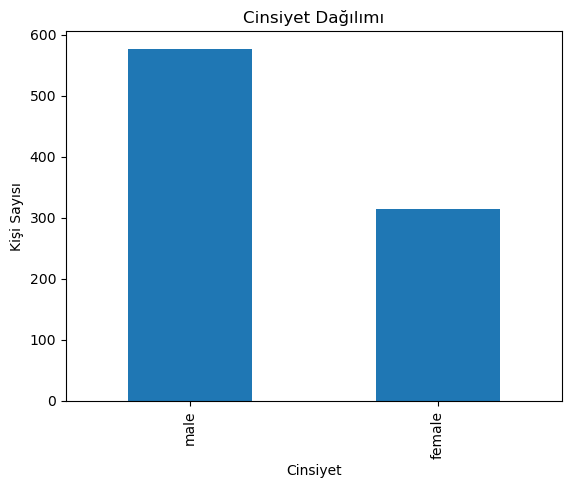

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)

df = sns.load_dataset("titanic")
df['sex'].value_counts().plot(kind='bar')
plt.title("Cinsiyet Dağılımı")
plt.xlabel("Cinsiyet")
plt.ylabel("Kişi Sayısı")
plt.show()

Pasta Grafiği (Pie Chart):

Daha görsel bir özet sağlar, örneğin cinsiyet değişkeninin dağılımını göstermek için kullanılabilir. 
Ancak, analitik karşılaştırmalar ve detaylı yorumlar için çubuk grafikler (bar chart) daha uygun bir tercih olacaktır.

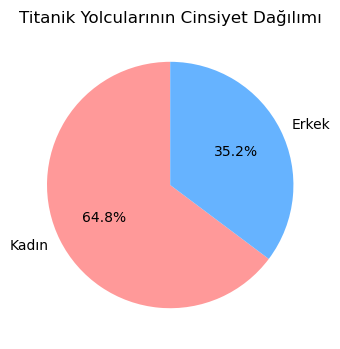

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

plt.figure(figsize=(6, 4))

gender_counts = df['sex'].value_counts()

colors = ['#ff9999','#66b3ff']

plt.pie(gender_counts, 
        labels=['Kadın', 'Erkek'],  # Türkçe etiketler
        autopct='%1.1f%%',          # Yüzde formatı
        colors=colors,              # Renkler
        startangle=90)              # Başlangıç açısı

plt.title('Titanik Yolcularının Cinsiyet Dağılımı')

plt.show()

🔢 Sayısal Değişkenler için Grafik Türleri

Sayısal değişkenlerin görselleştirilmesinde en sık kullanılan iki temel grafik türü histogram ve kutu grafiği (boxplot)'dir.
Bu iki grafik, istatistiksel analizlerde değişkenlerin dağılım yapısını anlamak için oldukça önemlidir. 
Veriyi tanımaya çalışırken, değişkenin hangi değer aralıklarında yoğunlaştığını ve uç değerlerin (aykırı gözlemlerin) olup olmadığını görmek isteriz.
İşte histogram ve kutu grafiği bu konuda bize yardımcı olur.

Histogram (plt.hist()): Histogram, bir sayısal değişkenin dağılımını gözlemlemek için kullanılır. 
Değişkenin aldığı değer aralıklarını, bu aralıklarda kaç gözlem olduğunu ve değişkenin hangi aralıklarda yoğunlaştığını gösterir.

Kutu Grafiği (Boxplot, plt.boxplot()): Dağılımı ve aykırı değerleri gösterir. 
Kutu grafiği, bir değişkenin minimum, birinci çeyrek (Q1), medyan, üçüncü çeyrek (Q3) ve maksimum değerlerini özetler. 
Ayrıca, çeyreklik değerler yardımıyla veri setinde yer alan aykırı değerleri de tespit etmemize olanak tanır. 
Aykırı değerler, genel dağılımın dışında kalan uç gözlemlerdir ve genellikle kutu dışında nokta (outlier) olarak gösterilir.

Histogram

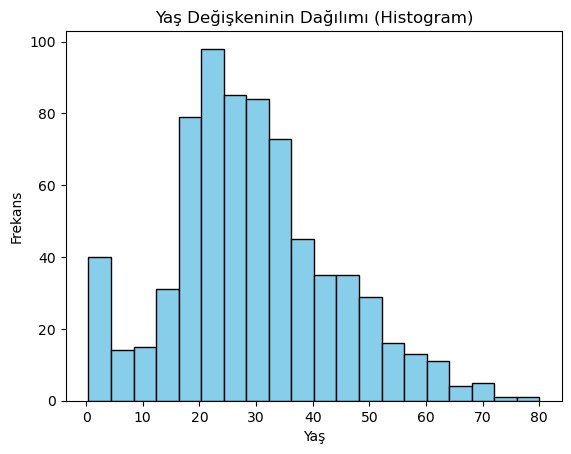

In [20]:
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=20, color="skyblue", edgecolor="black")
plt.title("Yaş Değişkeninin Dağılımı (Histogram)")
plt.xlabel("Yaş")
plt.ylabel("Frekans")
plt.show()

Kutu Grafiği

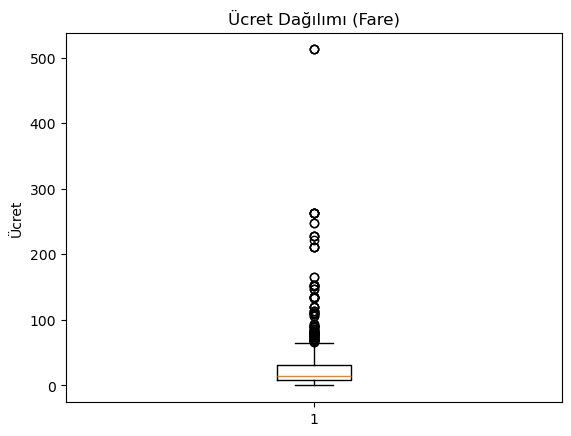

In [22]:
plt.boxplot(df["fare"])
plt.title("Ücret Dağılımı (Fare)")
plt.ylabel("Ücret")
plt.show()

Matplotlib'in Yapısı ve Özellikleri

Python dünyasında veri görselleştirme denince akla ilk gelen kütüphanelerden biri olan Matplotlib arka planda belirli katmanların birleşiminden oluşur. Matplotlib, sunduğu katmanlı yapı sayesinde oldukça esnek ve güçlü bir grafik oluşturma imkanı sağlar. Bu yapı, her görsel bileşenin bağımsız olarak kontrol edilebilmesini sağlar.

Katmanlı Yapı Ne Demektir?

Katmanlı yapı, bir görselin farklı bileşenlerinin (grafik çizimi, başlık, eksen etiketleri, grid yapısı, açıklamalar, renk/stil ayarları vb.) bağımsız olarak tanımlanması ve gerektiğinde düzenlenebilmesi anlamına gelir.
Bu yapı sayesinde, bir grafik sadece tek bir çizimle sınırlı kalmaz. Örneğin:
İlk katmanda çizgi, histogram ya da dağılım grafiği gibi temel görsel öğe yer alır.
İkinci katmanda grafiğe anlam katacak başlık eklenebilir.
Üçüncü katmanda X ve Y eksenlerine açıklayıcı etiketler yazılır.
Sonraki katmanlarda renk, çizgi tipi, kalınlık gibi stil detayları ayarlanabilir.
Gerekirse grid yapısı, açıklama kutuları (legend) veya önemli noktaları vurgulayan anotasyonlar eklenebilir.

Bu katmanlar birbirinden bağımsız şekilde yönetildiği için, özellikle görselleştirme sürecinde tekrar eden düzenlemeler daha kolay yapılabilir. Aynı zamanda profesyonel, okunabilir ve anlatımı güçlü grafikler üretme imkânı tanır. Matplotlib'in bu esnek yapısı, hem veri analizinde hem de sunumlarda etkili ve estetik grafikler oluşturmak isteyen kullanıcılar için büyük bir avantajdır.

Veri görselleştirme çalışmalarımızda sadece küçük çaplı örneklerle sınırlı kalmak yerine, daha ölçeklenebilir ve büyük veri analizlerine yönelik işler yapmak isteriz. Bu bağlamda Matplotlib kullanıcıya çok çeşitli grafik ve görselleştirme seçenekleri sunmaktadır.

Matplotlib'in bazı temel özellikleri:

1. plot() Fonksiyonu

Matplotlib'in en temel fonksiyonlarından biri plot() fonksiyonudur. Bu fonksiyon ile x ve y eksenlerine karşılık gelen değerleri kullanarak bir çizgi grafiği oluşturabiliriz.

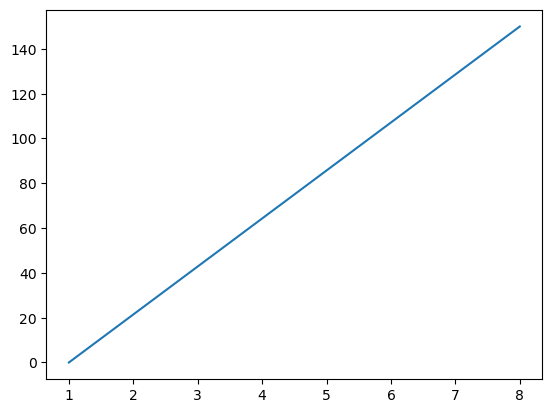

In [31]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 8])
y = np.array([0, 150])
plt.plot(x, y)
plt.show()

plt.plot(x, y, 'o') komutu ise belirttiğiniz x ve y koordinatlarında sadece noktaların işaretlenmesini sağlar. 
Bu durumda noktalar arasında çizgi çizilmez; sadece her bir veri noktası bir daire (marker) ile gösterilir. 
Özellikle veri setindeki noktaların tek tek vurgulanması gerektiğinde tercih edilir.

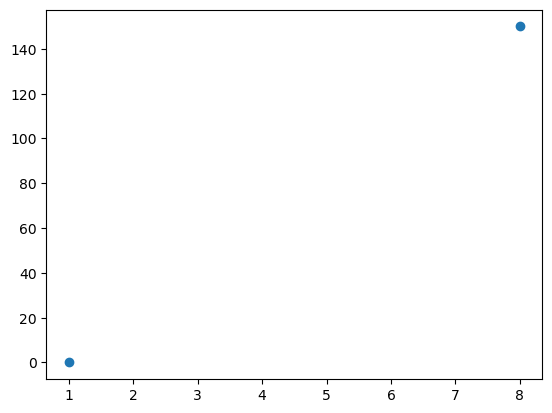

In [33]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 8])
y = np.array([0, 150])
plt.plot(x, y, 'o')  # Verilen koordinatlardaki noktaları işaretler, aralarına çizgi çizmez.
plt.show()

2. Marker (İşaretleyici) Özelliği

Veri noktalarını daha belirgin hale getirmek için marker parametresi kullanılır. 
Bu özellik sayesinde grafik üzerindeki her bir veri noktasını farklı sembollerle işaretleyebilirsiniz.

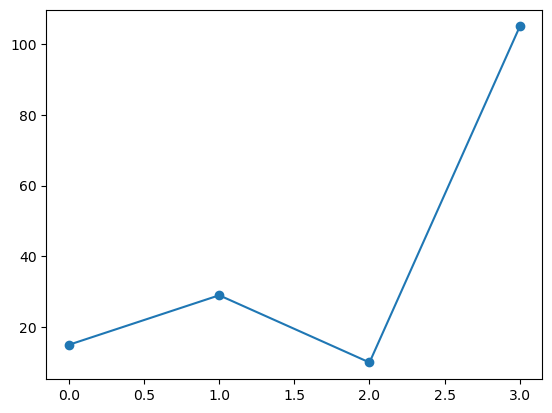

In [36]:
y = np.array([15, 29, 10, 105])
plt.plot(y, marker='o')
plt.show()

Kullanılabilir marker türleri:

In [38]:
markers = ['o', '*', '.', ',', 'x', 'X', '+', 'P', 's', 'D', 'd', 'p', 'H', 'h']

3. Çizgi Stilleri (Line Styles)

Matplotlib kütüphanesi, veri noktalarını birleştirirken kullanılabilecek çeşitli çizgi stilleri sunar. 
Bu çizgi tipleri sayesinde görselleştirmelerinizi daha anlamlı ve estetik hale getirebilirsiniz.

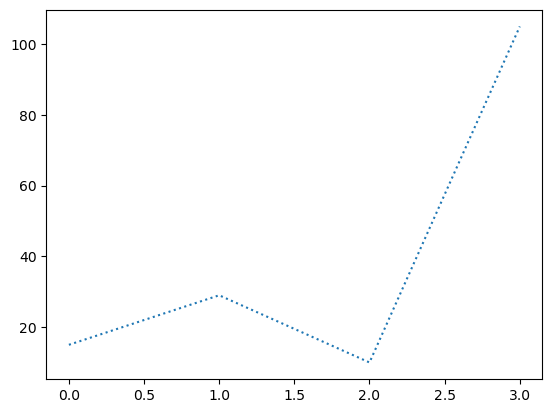

In [41]:
y = np.array([15, 29, 10, 105])
plt.plot(y, linestyle='dotted')  # Noktalı çizgi
plt.show()

Diğer seçenekler:

'dashed': Kesik çizgi
'dashdot': Nokta ve kesikli çizgi

Bu çizgilere renk vermek istersek:

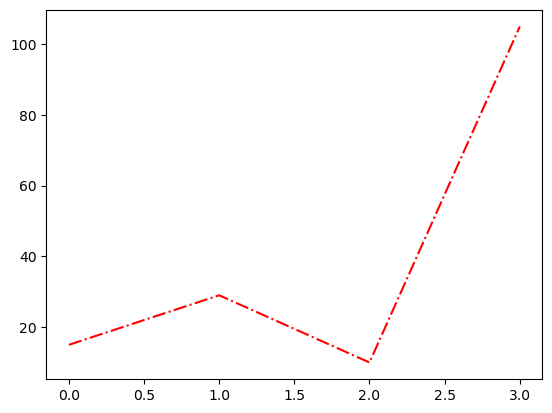

In [45]:
y = np.array([15, 29, 10, 105])
plt.plot(y, linestyle='dashdot', color='r') # Kırmızı çizgi
plt.show()

Grafikte kırmızı renkte kısa kesik ve noktalardan oluşan bir çizgi olarak görünür.

4. Birden Fazla Çizgi (Multiple Lines)

Aynı grafik üzerinde birden fazla çizim yapılabilir:

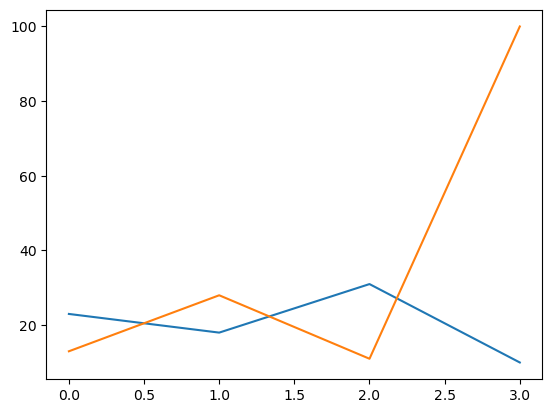

In [49]:
x = np.array([23, 18, 31, 10])
y = np.array([13, 28, 11, 100])
plt.plot(x)
plt.plot(y)
plt.show()

Bu şekilde birden fazla çizgiyi matplotlibin katmanlı yapısından dolayı kolay bir şekilde kullanabiliyoruz.

5. Grafik Etiketleme (Labels)

Grafiklerin okunabilirliğini artırmak için başlıklar ve eksen isimlendirmeleri kullanılabilir:

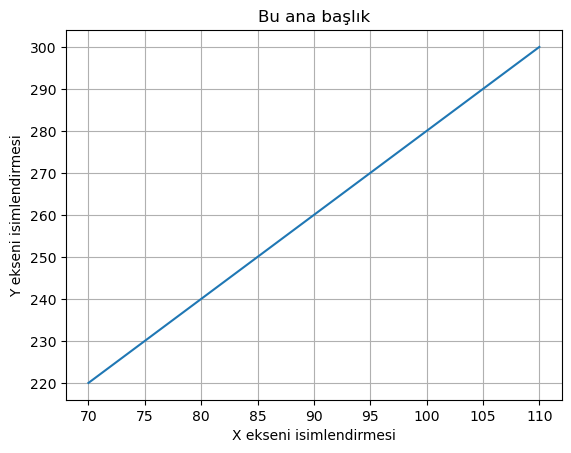

In [53]:
x = np.array([70, 75, 80, 85, 90, 95, 100, 105, 110])
y = np.array([220, 230, 240, 250, 260, 270, 280, 290, 300])

plt.plot(x, y)
plt.title("Bu ana başlık")
plt.xlabel("X ekseni isimlendirmesi")
plt.ylabel("Y ekseni isimlendirmesi")
plt.grid()  # Grafiğe ızgara çizgileri ekler.
plt.show()

6. Subplots (Alt Grafikler)

Aynı pencere içinde birden fazla grafiği düzenli bir şekilde görüntülemek için subplot() fonksiyonu kullanılır. 
Bu yöntem, farklı veri setlerini karşılaştırmak için oldukça faydalıdır.

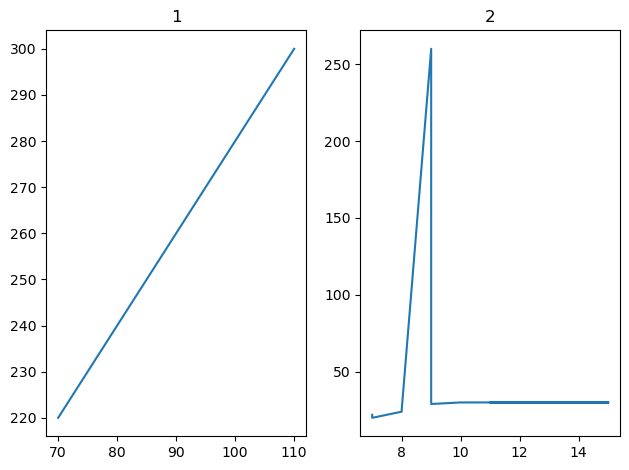

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Grafik 1
x = np.array([70, 75, 80, 85, 90, 95, 100, 105, 110])
y = np.array([220, 230, 240, 250, 260, 270, 280, 290, 300])
plt.subplot(1, 2, 1)  # 1 satır, 2 sütun, 1. grafik
plt.title("1")
plt.plot(x, y)

# Grafik 2
x = np.array([7, 7, 8, 8, 9, 9, 10, 15, 11, 15])
y = np.array([22, 20, 24, 25, 260, 29, 30, 30, 30, 30])
plt.subplot(1, 2, 2)  # 1 satır, 2 sütun, 2. grafik
plt.title("2")
plt.plot(x, y)

plt.tight_layout()
plt.show()

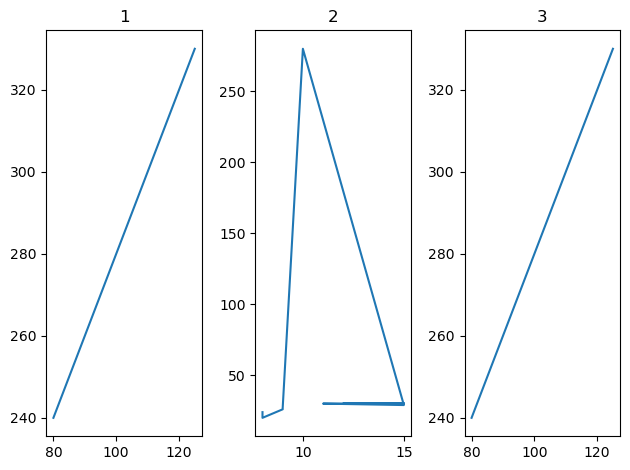

In [57]:
# Grafik 1
x = np.array([80, 85, 90, 95, 100, 105, 110, 115, 120, 125])
y = np.array([240, 250, 260, 270, 280, 290, 300, 310, 320, 330])
plt.subplot(1, 3, 1)  # 1 satır, 3 sütun, 1. grafik
plt.title("1")
plt.plot(x, y)

# Grafik 2
x = np.array([8, 8, 9, 9, 10, 15, 11, 15, 12, 15])
y = np.array([24, 20, 26, 27, 280, 29, 30, 30, 30, 30])
plt.subplot(1, 3, 2)  # 1 satır, 3 sütun, 2. grafik
plt.title("2")
plt.plot(x, y)

# Grafik 3
x = np.array([80, 85, 90, 95, 100, 105, 110, 115, 120, 125])
y = np.array([240, 250, 260, 270, 280, 290, 300, 310, 320, 330])
plt.subplot(1, 3, 3)  # 1 satır, 3 sütun, 3. grafik
plt.title("3")
plt.plot(x, y)

plt.tight_layout()
plt.show()

Seaborn

Seaborn, veri görselleştirme işleri için kullanılan yüksek seviyeli bir kütüphanedir. 
Daha az çaba harcayarak, kolayca etkileyici grafikler oluşturma imkanı sağlar.

Kategorik Değişkenin Görselleştirilmesi

Örneğin, cinsiyet kategorik değişkeninin sınıflarını görselleştirmek için:

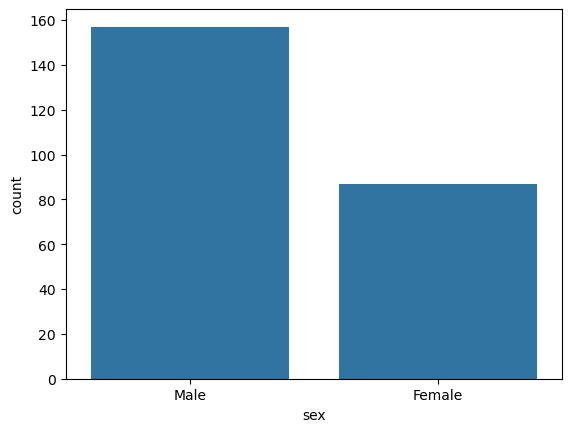

In [62]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
df = sns.load_dataset('tips')

df["sex"].value_counts()  # Kategorik değişkenin sayısını görselleştir
sns.countplot(x=df["sex"], data=df)  # Görselleştirmek istediğimiz değişkeni ve ilgili veriyi buraya giriyoruz.
plt.show()

Bu işlemi Matplotlib ile de şu şekilde yapabilirsiniz:

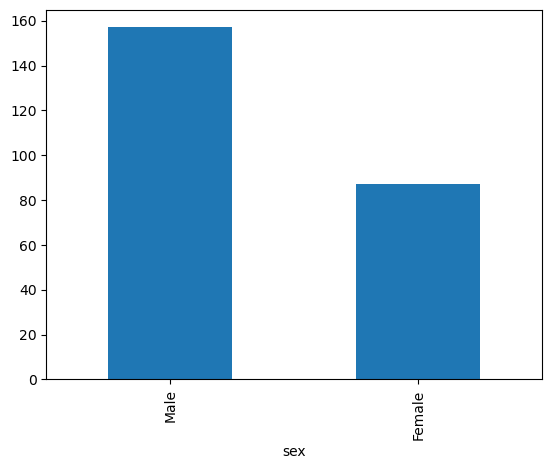

In [64]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
df = sns.load_dataset('tips')

df["sex"].value_counts().plot(kind='bar')  # Bar grafiği ile görselleştirme
plt.show()

Sayısal Değişkenin Görselleştirilmesi

Elimizde sayısal bir değişken varsa, dağılımını görmek için histogram veya kutu grafiği (boxplot) kullanabiliriz. 
Böylece ilgili sayısal değişkenin dağılımı ile ilgili bilgi sahibi oluruz.

Boxplot ile Görselleştirme

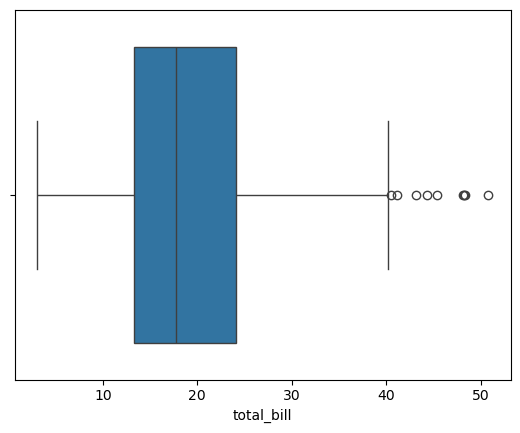

In [68]:
sns.boxplot(x=df["total_bill"])  # Boxplot
plt.show()

Veriyi ve değişkenleri anlamak için elimizde üç temel görselleştirme yaklaşımı öne çıkar:
value_counts ve countplot – Kategorik değişkenlerin sınıf dağılımını görselleştirmek için,
Histogram - Sayısal değişkenlerin dağılımını incelemek için,
Boxplot - Sayısal değişkenlerin yayılımını ve aykırı değerlerini analiz etmek için.

Bu üç temel yaklaşım sayesinde, veri analizi sürecinde ihtiyaç duyacağınız pek çok bilgiye kolaylıkla ulaşabilir; değişkenleri daha iyi anlayarak veri setindeki eğilimleri ve farkları hızlıca görebilirsiniz.

Sonuç olarak veri görselleştirme, yalnızca grafik çizmekten ibaret değildir; aynı zamanda veriyi anlamanın, anlatmanın ve etkili kararlar almanın en güçlü yollarından biridir. Bu yazıda Matplotlib ve Seaborn kütüphaneleriyle temel grafik türlerini kullanarak nasıl daha okunabilir ve anlamlı görseller oluşturabileceğimizi birlikte inceledik. Veri analizi sürecinizin başlangıcında bu araçları etkili bir şekilde kullanarak, daha karmaşık analizler için sağlam bir temel oluşturabilirsiniz.
Unutmayın ki, veri görselleştirme yalnızca sonuçları göstermekle kalmaz; aynı zamanda veriyi anlamanızı, başkalarına anlatmanızı ve karar alıcıları bilgilendirmenizi de sağlar. Bu yüzden görselleştirmeyi yalnızca bir analiz aracı olarak değil, veri hikayenizi anlatan güçlü bir iletişim aracı olarak da görmelisiniz.